# M-04 Temporal Fall Detection

M-03이 생성한 사람별 COCO-17 keypoint 시퀀스를 학습 가능한 temporal window로 변환하는 전처리 Notebook

## 구현 범위

1. Colab·로컬 경로와 최소 package 설정
2. URFD RGB·동기화·frame label 무결성 검증
3. M-03 RTMPose-t 입력·출력 계약 재사용
4. `track_id`별 10 FPS COCO-17 keypoint sequence 생성
5. confidence mask와 temporal 파생 특징 계산
6. 2초·3초 window와 다중 target 생성
7. 원본 sequence 단위 train·validation·test 분리
8. PyTorch `Dataset`·`DataLoader`와 학습 준비 조건 확인

이 Notebook은 model class·optimizer·training loop를 실행하기 직전에서 멈춘다.

# 1. 환경 설정

Colab과 로컬 Jupyter에서 동일한 project root를 찾고, Git에서 제외되는 raw·processed dataset 경로를 준비

In [1]:
import importlib.util
import os
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from google.colab import drive

    DRIVE_MOUNT_POINT = Path("/content/drive")
    drive.mount(str(DRIVE_MOUNT_POINT))
    PROJECT_ROOT = (
        DRIVE_MOUNT_POINT / "MyDrive" / "Colab Notebooks" / "wardy-pose-fall"
    )
    runtime_name = "Google Colab"
else:
    def find_project_root(start_path: Path) -> Path:
        for candidate in (start_path, *start_path.parents):
            if (candidate / ".git").exists() and (candidate / "ml" / "notebook").is_dir():
                return candidate
        raise FileNotFoundError(
            "wardy 저장소 내부에서 Jupyter 실행 또는 WARDY_PROJECT_ROOT 설정 필요"
        )

    search_start = Path(
        os.environ.get("WARDY_PROJECT_ROOT", Path.cwd())
    ).expanduser().resolve()
    PROJECT_ROOT = find_project_root(search_start)
    runtime_name = "Local Jupyter"

REQUIREMENTS_PATH = PROJECT_ROOT / "ml" / "requirements" / "m04.txt"
RAW_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed" / "m04"
POSE_MODEL_DIR = PROJECT_ROOT / "ml" / "checkpoints" / "rtmpose-t-onnx"

# source와 분리된 cache·dataset directory를 한 번에 준비
for directory in (RAW_DATA_DIR, PROCESSED_DATA_DIR, POSE_MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Runtime: {runtime_name}")
print(f"Project repository: {PROJECT_ROOT.name}")
print(f"Requirements: {REQUIREMENTS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Raw dataset directory: {RAW_DATA_DIR.relative_to(PROJECT_ROOT)}")
print(f"Processed dataset directory: {PROCESSED_DATA_DIR.relative_to(PROJECT_ROOT)}")

Runtime: Local Jupyter
Project repository: wardy-pose-fall
Requirements: ml/requirements/m04.txt
Raw dataset directory: ml/data/raw
Processed dataset directory: ml/data/processed/m04


## 최소 package 설치

M-03 ONNX 추론 package에 temporal dataset 준비용 PyTorch와 시각화 package만 추가

In [2]:
# 현재 Jupyter kernel에 M-04 최소 의존성을 설치
%pip install --quiet --disable-pip-version-check -r {REQUIREMENTS_PATH}

Note: you may need to restart the kernel to use updated packages.


## 실행 환경 확인

RTMPose는 ONNX Runtime provider를 사용하고, 이후 temporal model 학습 device는 PyTorch에서 별도로 선택

In [3]:
import platform
import sys
from importlib.metadata import version

import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch

# ONNX pose inference와 PyTorch temporal training의 device를 독립적으로 선택
available_providers = ort.get_available_providers()
if platform.system() == "Darwin" and "CoreMLExecutionProvider" in available_providers:
    POSE_PROVIDERS = ["CoreMLExecutionProvider", "CPUExecutionProvider"]
else:
    POSE_PROVIDERS = ["CPUExecutionProvider"]

if torch.cuda.is_available():
    TEMPORAL_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    TEMPORAL_DEVICE = torch.device("mps")
else:
    TEMPORAL_DEVICE = torch.device("cpu")

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()} ({platform.machine()})")
print(f"NumPy/OpenCV: {np.__version__}/{cv2.__version__}")
print(f"ONNX Runtime: {version('onnxruntime')}")
print(f"Pose providers: {POSE_PROVIDERS}")
print(f"PyTorch: {torch.__version__}")
print(f"Temporal device: {TEMPORAL_DEVICE}")

Python: 3.10.20
Platform: macOS-26.5.2-arm64-arm-64bit (arm64)
NumPy/OpenCV: 1.26.4/4.11.0
ONNX Runtime: 1.23.2
Pose providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider']
PyTorch: 2.2.2
Temporal device: mps


# 2. URFD sample과 label 계약

## URFD RGB sample 다운로드

공식 출처: https://fenix.ur.edu.pl/~mkepski/ds/uf.html

정면 camera `fall-01-cam0-rgb.zip`, 동기화 시각과 공식 frame label을 내려받아 하나의 sequence 계약으로 검증

In [4]:
import hashlib
from tempfile import NamedTemporaryFile
from urllib.request import urlretrieve
from zipfile import ZipFile

URFD_DIR = RAW_DATA_DIR / "urfd"
URFD_BASE_URL = "https://fenix.ur.edu.pl/~mkepski/ds/data"
SAMPLE_ARCHIVE = URFD_DIR / "fall-01-cam0-rgb.zip"
FALL_LABELS_PATH = URFD_DIR / "urfall-cam0-falls.csv"
SAMPLE_SYNC_PATH = URFD_DIR / "fall-01-data.csv"
SAMPLE_SHA256 = "e5ff96108d322d7fe5ba6871a4c50d9c26c59e74abea03d2b69b6be56521736f"
FALL_LABELS_SHA256 = "4ed29af7040098ba0150d1030eeadd97bbfde5c3a4fb9b07df786d673e22a65c"
SAMPLE_SYNC_SHA256 = "60e156223725e401155b4fd25a672c498ed5b4e17897337c6971d90041818bcc"

URFD_DIR.mkdir(parents=True, exist_ok=True)

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

# 중단된 download를 cache로 오인하지 않도록 임시 파일을 검증한 뒤 교체
def download_verified(url: str, destination: Path, expected_sha256: str) -> str:
    if destination.exists() and sha256(destination) == expected_sha256:
        return "cached"

    with NamedTemporaryFile(dir=destination.parent, suffix=".part", delete=False) as file:
        partial_path = Path(file.name)
    try:
        urlretrieve(url, partial_path)
        downloaded_hash = sha256(partial_path)
        if downloaded_hash != expected_sha256:
            raise RuntimeError(f"SHA-256 mismatch for {destination.name}: {downloaded_hash}")
        partial_path.replace(destination)
    finally:
        partial_path.unlink(missing_ok=True)
    return "downloaded"

print("Verified download helper: ready")

Verified download helper: ready


In [5]:
# RGB·전체 fall label·fall-01 timestamp를 각각 고정 hash로 확보
download_states = {
    "rgb": download_verified(
        f"{URFD_BASE_URL}/{SAMPLE_ARCHIVE.name}", SAMPLE_ARCHIVE, SAMPLE_SHA256
    ),
    "labels": download_verified(
        f"{URFD_BASE_URL}/{FALL_LABELS_PATH.name}", FALL_LABELS_PATH, FALL_LABELS_SHA256
    ),
    "sync": download_verified(
        f"{URFD_BASE_URL}/{SAMPLE_SYNC_PATH.name}", SAMPLE_SYNC_PATH, SAMPLE_SYNC_SHA256
    ),
}

print(f"Download states: {download_states}")

Download states: {'rgb': 'cached', 'labels': 'cached', 'sync': 'cached'}


In [6]:
# file hash 다음에는 ZIP 내부 member까지 열어 실제 frame 손상을 검사
with ZipFile(SAMPLE_ARCHIVE) as archive:
    bad_member = archive.testzip()
    if bad_member is not None:
        raise ValueError(f"Corrupted ZIP member: {bad_member}")
    png_count = sum(name.lower().endswith(".png") for name in archive.namelist())

# 재현에 필요한 path·hash·frame 수만 상대 경로로 출력
print(f"Archive: {SAMPLE_ARCHIVE.relative_to(PROJECT_ROOT)}")
print(f"Archive SHA-256: {sha256(SAMPLE_ARCHIVE)}")
print(f"Labels SHA-256: {sha256(FALL_LABELS_PATH)}")
print(f"Sync SHA-256: {sha256(SAMPLE_SYNC_PATH)}")
print(f"Size: {SAMPLE_ARCHIVE.stat().st_size / 1024**2:.2f} MiB")
print(f"PNG frames: {png_count}")

Archive: ml/data/raw/urfd/fall-01-cam0-rgb.zip
Archive SHA-256: e5ff96108d322d7fe5ba6871a4c50d9c26c59e74abea03d2b69b6be56521736f
Labels SHA-256: 4ed29af7040098ba0150d1030eeadd97bbfde5c3a4fb9b07df786d673e22a65c
Sync SHA-256: 60e156223725e401155b4fd25a672c498ed5b4e17897337c6971d90041818bcc
Size: 55.05 MiB
PNG frames: 160


## frame·timestamp·label 정렬

공식 label `-1`은 눕지 않음, `0`은 낙상 전이, `1`은 바닥에 누운 상태이며 RGB frame 번호와 동기화 timestamp를 같은 row로 결합

In [7]:
import csv
from collections import Counter

# fall-01에 해당하는 공식 posture label과 camera timestamp만 선택
with FALL_LABELS_PATH.open(newline="") as file:
    label_rows = [row for row in csv.reader(file) if row[0] == "fall-01"]

with SAMPLE_SYNC_PATH.open(newline="") as file:
    sync_rows = list(csv.reader(file))

with ZipFile(SAMPLE_ARCHIVE) as archive:
    frame_names = sorted(name for name in archive.namelist() if name.lower().endswith(".png"))

frame_numbers = np.asarray([int(Path(name).stem.rsplit("-", 1)[1]) for name in frame_names])
label_by_frame = {int(row[1]): int(row[2]) for row in label_rows}
timestamp_by_frame = {int(row[0]): int(row[1]) for row in sync_rows}
expected_frames = np.arange(1, len(frame_names) + 1)

assert np.array_equal(frame_numbers, expected_frames)
assert set(frame_numbers) == set(label_by_frame) == set(timestamp_by_frame)

official_labels = np.asarray([label_by_frame[number] for number in frame_numbers], dtype=np.int8)
timestamps_ms = np.asarray([timestamp_by_frame[number] for number in frame_numbers], dtype=np.int64)
source_fps = 1000.0 / float(np.median(np.diff(timestamps_ms)))
label_transitions = [
    (int(frame_numbers[index]), int(official_labels[index]))
    for index in range(len(official_labels))
    if index == 0 or official_labels[index] != official_labels[index - 1]
]

print(f"Aligned frames: {len(frame_numbers)}")
print(f"Source FPS: {source_fps:.3f}")
print(f"Label counts: {dict(sorted(Counter(official_labels.tolist()).items()))}")
print(f"Label transitions (frame, label): {label_transitions}")
print("URFD frame contract: PASS")

Aligned frames: 160
Source FPS: 30.303
Label counts: {-1: 82, 0: 30, 1: 48}
Label transitions (frame, label): [(1, -1), (83, 0), (113, 1)]
URFD frame contract: PASS


# 3. M-03 keypoint 입력 계약

M-03과 같은 RTMPose-t ONNX model·SHA-256·COCO-17 순서를 재사용한다. M-01 연결 전 smoke test는 `full_frame_fallback` bbox를 명시적으로 기록하며 최종 학습 데이터로 채택하지 않는다.

In [8]:
MODEL_URL = (
    "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/"
    "rtmpose-t_simcc-body7_pt-body7_420e-256x192-026a1439_20230504.zip"
)
MODEL_ARCHIVE = POSE_MODEL_DIR / "rtmpose-t.zip"
MODEL_PATH = (
    POSE_MODEL_DIR / "20230831" / "rtmpose_onnx"
    / "rtmpose-t_simcc-body7_pt-body7_420e-256x192-026a1439_20230504"
    / "end2end.onnx"
)
MODEL_ARCHIVE_SHA256 = "937003a70832d9cc34ea16927f504792f3133e92dda1b9c626236bbbe9e805cb"
MODEL_SHA256 = "a6c2f6a3896a4d51131d14d7a80a3d08b50f559af5a58a45d5b098aef510a70f"

model_archive_state = download_verified(MODEL_URL, MODEL_ARCHIVE, MODEL_ARCHIVE_SHA256)

# 검증된 archive만 사용하고 extraction 경로가 model cache 밖으로 나가지 않게 확인
if not MODEL_PATH.exists():
    model_root = POSE_MODEL_DIR.resolve()
    with ZipFile(MODEL_ARCHIVE) as archive:
        for member in archive.infolist():
            member_path = (POSE_MODEL_DIR / member.filename).resolve()
            if member_path != model_root and model_root not in member_path.parents:
                raise ValueError(f"Unsafe model archive member: {member.filename}")
        archive.extractall(POSE_MODEL_DIR)

if sha256(MODEL_PATH) != MODEL_SHA256:
    raise RuntimeError(f"Model SHA-256 mismatch: {sha256(MODEL_PATH)}")

pose_session = ort.InferenceSession(str(MODEL_PATH), providers=POSE_PROVIDERS)
pose_input_name = pose_session.get_inputs()[0].name
pose_output_names = [output.name for output in pose_session.get_outputs()]

print(f"Model archive: {model_archive_state}")
print(f"Model: {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Model SHA-256: {sha256(MODEL_PATH)}")
print(f"Session providers: {pose_session.get_providers()}")
print("M-03 pose session: ready")

Model archive: cached
Model: ml/checkpoints/rtmpose-t-onnx/20230831/rtmpose_onnx/rtmpose-t_simcc-body7_pt-body7_420e-256x192-026a1439_20230504/end2end.onnx
Model SHA-256: a6c2f6a3896a4d51131d14d7a80a3d08b50f559af5a58a45d5b098aef510a70f
Session providers: ['CoreMLExecutionProvider', 'CPUExecutionProvider']
M-03 pose session: ready


2026-08-11 13:34:39.875 Python[76807:34497308] 2026-08-11 13:34:39.875068 [W:onnxruntime:, coreml_execution_provider.cc:113 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 5 number of nodes in the graph: 168 number of nodes supported by CoreML: 125


In [9]:
MODEL_INPUT_SIZE = np.array([192, 256], dtype=np.float32)  # width, height
BBOX_PADDING = 1.25
IMAGE_MEAN = np.array([123.675, 116.28, 103.53], dtype=np.float32)
IMAGE_STD = np.array([58.395, 57.12, 57.375], dtype=np.float32)
SIMCC_SPLIT_RATIO = 2.0
COCO_KEYPOINT_NAMES = (
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
)

# M-03과 동일한 bbox padding·affine transform·RGB normalization
def bbox_xyxy_to_center_scale(bbox_xyxy: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x1, y1, x2, y2 = bbox_xyxy.astype(np.float32)
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Invalid bbox_xyxy: {bbox_xyxy}")
    center = np.array([(x1 + x2) * 0.5, (y1 + y2) * 0.5], dtype=np.float32)
    scale = np.array([x2 - x1, y2 - y1], dtype=np.float32) * BBOX_PADDING
    aspect_ratio = float(MODEL_INPUT_SIZE[0] / MODEL_INPUT_SIZE[1])
    if scale[0] > scale[1] * aspect_ratio:
        scale[1] = scale[0] / aspect_ratio
    else:
        scale[0] = scale[1] * aspect_ratio
    return center, scale

def third_point(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    direction = a - b
    return b + np.array([-direction[1], direction[0]], dtype=np.float32)

def affine_matrix(center: np.ndarray, scale: np.ndarray) -> np.ndarray:
    dst_w, dst_h = MODEL_INPUT_SIZE
    src_direction = np.array([0.0, -0.5 * scale[0]], dtype=np.float32)
    dst_direction = np.array([0.0, -0.5 * dst_w], dtype=np.float32)
    src = np.stack([center, center + src_direction, third_point(center, center + src_direction)])
    dst_center = np.array([dst_w * 0.5, dst_h * 0.5], dtype=np.float32)
    dst = np.stack([dst_center, dst_center + dst_direction, third_point(dst_center, dst_center + dst_direction)])
    return cv2.getAffineTransform(src.astype(np.float32), dst.astype(np.float32))

print(f"COCO keypoints: {len(COCO_KEYPOINT_NAMES)}")
print(f"Pose input size: {tuple(MODEL_INPUT_SIZE.astype(int))}")
print("BBox/affine helpers: ready")

COCO keypoints: 17
Pose input size: (192, 256)
BBox/affine helpers: ready


In [10]:
# 원본 frame과 bbox를 ONNX가 받는 NCHW float32 tensor로 변환
def preprocess_pose(frame: np.ndarray, bbox_xyxy: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    center, scale = bbox_xyxy_to_center_scale(bbox_xyxy)
    width, height = MODEL_INPUT_SIZE.astype(int)
    crop = cv2.warpAffine(frame, affine_matrix(center, scale), (width, height))
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB).astype(np.float32)
    tensor = np.ascontiguousarray(((crop_rgb - IMAGE_MEAN) / IMAGE_STD).transpose(2, 0, 1)[None])
    return tensor.astype(np.float32), center, scale

# 두 SimCC 축의 최대 응답을 원본 frame 좌표와 confidence로 복원
def decode_simcc(simcc_x: np.ndarray, simcc_y: np.ndarray, center: np.ndarray, scale: np.ndarray) -> np.ndarray:
    locations = np.stack([np.argmax(simcc_x, axis=-1), np.argmax(simcc_y, axis=-1)], axis=-1).astype(np.float32)
    scores = np.minimum(np.max(simcc_x, axis=-1), np.max(simcc_y, axis=-1))
    model_xy = locations / SIMCC_SPLIT_RATIO
    frame_xy = model_xy / MODEL_INPUT_SIZE * scale + center - scale * 0.5
    return np.concatenate([frame_xy, scores[..., None]], axis=-1)

print("M-03 preprocess/decode contract: ready")

M-03 preprocess/decode contract: ready


# 4. COCO-17 keypoint sequence 생성

원본 약 30 FPS sequence를 첫 baseline의 10 FPS로 sampling하고, 동일한 `track_id`에 frame·timestamp·bbox·keypoint·pose quality를 연결

In [11]:
TARGET_FPS = 10.0
TRACK_ID = 1
BBOX_STRATEGY = "full_frame_fallback"
sampling_step = max(1, int(round(source_fps / TARGET_FPS)))
sample_indices = np.arange(0, len(frame_names), sampling_step)
POSE_CACHE_PATH = PROCESSED_DATA_DIR / "fall-01_rtmpose-t_10fps_full-frame.npz"

# cache는 source·model·sampling·bbox 계약이 모두 같은 경우에만 재사용
cache_is_valid = False
if POSE_CACHE_PATH.exists():
    with np.load(POSE_CACHE_PATH, allow_pickle=False) as cache:
        cache_is_valid = (
            cache["source_sha256"].item() == SAMPLE_SHA256
            and cache["model_sha256"].item() == MODEL_SHA256
            and int(cache["sampling_step"].item()) == sampling_step
            and cache["bbox_strategy"].item() == BBOX_STRATEGY
        )

print(f"Pose cache contract valid: {cache_is_valid}")

Pose cache contract valid: True


In [12]:
# cache miss일 때만 RGB archive를 열고 sampled frame을 순서대로 pose 추론
def infer_sampled_pose_sequence() -> dict[str, np.ndarray]:
    collected_bboxes = []
    collected_keypoints = []
    collected_quality = []
    with ZipFile(SAMPLE_ARCHIVE) as archive:
        for source_index in sample_indices:
            image_bytes = np.frombuffer(archive.read(frame_names[source_index]), dtype=np.uint8)
            frame_bgr = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
            if frame_bgr is None:
                raise RuntimeError(f"Unable to decode {frame_names[source_index]}")

            # M-01 미연결 상태를 숨기지 않고 fallback bbox를 각 frame 결과에 기록
            frame_height, frame_width = frame_bgr.shape[:2]
            bbox_xyxy = np.array([0, 0, frame_width - 1, frame_height - 1], dtype=np.float32)
            pose_tensor, bbox_center, bbox_scale = preprocess_pose(frame_bgr, bbox_xyxy)
            simcc_x, simcc_y = pose_session.run(
                pose_output_names, {pose_input_name: pose_tensor}
            )
            keypoints_xyc = decode_simcc(simcc_x, simcc_y, bbox_center, bbox_scale)[0]
            collected_bboxes.append(bbox_xyxy)
            collected_keypoints.append(keypoints_xyc)
            collected_quality.append(float(np.mean(keypoints_xyc[:, 2])))

    return {
        "frame_numbers": frame_numbers[sample_indices].astype(np.int32),
        "timestamps_ms": timestamps_ms[sample_indices].astype(np.int64),
        "bboxes_xyxy": np.asarray(collected_bboxes, dtype=np.float32),
        "keypoints_xyc": np.asarray(collected_keypoints, dtype=np.float32),
        "pose_quality": np.asarray(collected_quality, dtype=np.float32),
        "official_labels": official_labels[sample_indices].astype(np.int8),
    }

print("Sequence inference helper: ready")

Sequence inference helper: ready


In [13]:
# cache와 새 inference 결과를 동일한 key의 sequence data로 통일
if cache_is_valid:
    with np.load(POSE_CACHE_PATH, allow_pickle=False) as cache:
        sequence_data = {key: cache[key] for key in (
            "frame_numbers", "timestamps_ms", "bboxes_xyxy",
            "keypoints_xyc", "pose_quality", "official_labels",
        )}
    pose_cache_state = "cached"
else:
    sequence_data = infer_sampled_pose_sequence()

    # 새 결과에는 source·model·sampling·bbox provenance를 함께 저장
    np.savez_compressed(
        POSE_CACHE_PATH,
        source_sha256=np.asarray(SAMPLE_SHA256),
        model_sha256=np.asarray(MODEL_SHA256),
        sampling_step=np.asarray(sampling_step),
        bbox_strategy=np.asarray(BBOX_STRATEGY),
        **sequence_data,
    )
    pose_cache_state = "generated"

sequence_frame_numbers = sequence_data["frame_numbers"]
sequence_timestamps_ms = sequence_data["timestamps_ms"]
sequence_bboxes = sequence_data["bboxes_xyxy"]
sequence_keypoints = sequence_data["keypoints_xyc"]
sequence_pose_quality = sequence_data["pose_quality"]
sequence_labels = sequence_data["official_labels"]
print(f"Pose cache state: {pose_cache_state}")

Pose cache state: cached


In [14]:
# frame 수·COCO-17 shape·timestamp 단조 증가를 downstream 전제조건으로 고정
assert sequence_keypoints.shape == (len(sample_indices), 17, 3)
assert np.isfinite(sequence_keypoints).all()
assert np.all(np.diff(sequence_timestamps_ms) > 0)

effective_fps = 1000.0 / float(np.median(np.diff(sequence_timestamps_ms)))
print(f"Pose cache: {pose_cache_state}")
print(f"Cache path: {POSE_CACHE_PATH.relative_to(PROJECT_ROOT)}")
print(f"BBox strategy: {BBOX_STRATEGY}")
print(f"Sequence frames: {len(sequence_frame_numbers)} at {effective_fps:.3f} FPS")
print(f"Keypoints: {sequence_keypoints.shape}")
print(f"Mean pose quality: {sequence_pose_quality.mean():.4f}")
print("M-03 sequence tensor contract: PASS (smoke-test only)")

Pose cache: cached
Cache path: ml/data/processed/m04/fall-01_rtmpose-t_10fps_full-frame.npz
BBox strategy: full_frame_fallback
Sequence frames: 54 at 10.000 FPS
Keypoints: (54, 17, 3)
Mean pose quality: 0.1683
M-03 sequence tensor contract: PASS (smoke-test only)


# 5. confidence mask와 temporal 특징

관절 좌표를 bbox 중심·폭·높이로 정규화하고, 낮은 confidence 좌표는 mask와 함께 전달한다. 몸통 기울기·엉덩이 하강·가속도·bbox 변화·관절 이동량을 model 입력 뒤쪽에 추가한다.

In [15]:
KEYPOINT_CONFIDENCE_THRESHOLD = 0.30
timestamps_s = sequence_timestamps_ms.astype(np.float64) / 1000.0
bbox_widths = np.maximum(sequence_bboxes[:, 2] - sequence_bboxes[:, 0], 1.0)
bbox_heights = np.maximum(sequence_bboxes[:, 3] - sequence_bboxes[:, 1], 1.0)
bbox_centers = np.stack([
    (sequence_bboxes[:, 0] + sequence_bboxes[:, 2]) * 0.5,
    (sequence_bboxes[:, 1] + sequence_bboxes[:, 3]) * 0.5,
], axis=-1)

joint_confidence = sequence_keypoints[:, :, 2]
joint_mask = (joint_confidence >= KEYPOINT_CONFIDENCE_THRESHOLD).astype(np.float32)
normalized_xy = sequence_keypoints[:, :, :2].copy()
normalized_xy[:, :, 0] = (normalized_xy[:, :, 0] - bbox_centers[:, None, 0]) / bbox_widths[:, None]
normalized_xy[:, :, 1] = (normalized_xy[:, :, 1] - bbox_centers[:, None, 1]) / bbox_heights[:, None]
normalized_xy *= joint_mask[:, :, None]

# 양쪽 관절 중 보이는 쪽만 사용하고 둘 다 누락되면 뒤 단계에서 보간
def pair_center(left_index: int, right_index: int) -> tuple[np.ndarray, np.ndarray]:
    pair_mask = joint_mask[:, [left_index, right_index]]
    weights = pair_mask / np.maximum(pair_mask.sum(axis=1, keepdims=True), 1.0)
    center = (normalized_xy[:, [left_index, right_index]] * weights[:, :, None]).sum(axis=1)
    valid = pair_mask.sum(axis=1) > 0
    return center, valid

def interpolate_valid(values: np.ndarray, valid: np.ndarray) -> np.ndarray:
    valid_indices = np.flatnonzero(valid)
    if len(valid_indices) == 0:
        return np.zeros_like(values, dtype=np.float32)
    return np.interp(np.arange(len(values)), valid_indices, values[valid_indices]).astype(np.float32)

print(f"Normalized keypoints: {normalized_xy.shape}")
print(f"Confidence mask threshold: {KEYPOINT_CONFIDENCE_THRESHOLD}")

Normalized keypoints: (54, 17, 2)
Confidence mask threshold: 0.3


In [16]:
# 어깨·엉덩이 중심으로 몸통 방향과 수직 이동 특징을 계산
shoulder_center, shoulder_valid = pair_center(5, 6)
hip_center, hip_valid = pair_center(11, 12)
shoulder_y = interpolate_valid(shoulder_center[:, 1], shoulder_valid)
hip_y = interpolate_valid(hip_center[:, 1], hip_valid)
torso_dx = interpolate_valid(hip_center[:, 0] - shoulder_center[:, 0], shoulder_valid & hip_valid)
torso_dy = interpolate_valid(hip_center[:, 1] - shoulder_center[:, 1], shoulder_valid & hip_valid)
torso_tilt = np.arctan2(np.abs(torso_dx), np.maximum(np.abs(torso_dy), 1e-6)) / (np.pi / 2.0)
hip_vertical_velocity = np.gradient(hip_y, timestamps_s).astype(np.float32)
hip_vertical_acceleration = np.gradient(hip_vertical_velocity, timestamps_s).astype(np.float32)
bbox_aspect = (bbox_widths / bbox_heights).astype(np.float32)
bbox_height_ratio = (bbox_heights / bbox_heights.max()).astype(np.float32)
bbox_height_velocity = np.gradient(bbox_height_ratio, timestamps_s).astype(np.float32)
visible_ratio = joint_mask.mean(axis=1).astype(np.float32)
body_center_y = ((shoulder_y + hip_y) * 0.5).astype(np.float32)
low_posture_score = np.clip((body_center_y + 0.10) / 0.55, 0.0, 1.0).astype(np.float32)

# 인접 frame에서 동시에 보이는 관절만 사용해 평균 이동 속도를 계산
joint_delta = np.diff(normalized_xy, axis=0, prepend=normalized_xy[[0]])
joint_pair_mask = joint_mask * np.vstack([joint_mask[[0]], joint_mask[:-1]])
joint_motion = (
    np.linalg.norm(joint_delta, axis=-1) * joint_pair_mask
).sum(axis=1) / np.maximum(joint_pair_mask.sum(axis=1), 1.0)
joint_motion /= np.maximum(np.gradient(timestamps_s), 1e-6)

derived_features = np.column_stack([
    torso_tilt, shoulder_y, hip_y, hip_vertical_velocity, hip_vertical_acceleration,
    bbox_aspect, bbox_height_ratio, bbox_height_velocity, visible_ratio,
    body_center_y, low_posture_score, joint_motion,
]).astype(np.float32)
derived_feature_names = (
    "torso_tilt", "shoulder_y", "hip_y", "hip_vertical_velocity",
    "hip_vertical_acceleration", "bbox_aspect", "bbox_height_ratio",
    "bbox_height_velocity", "visible_ratio", "body_center_y",
    "low_posture_score", "joint_motion",
)

print(f"Derived feature matrix: {derived_features.shape}")
print(f"Derived features: {derived_feature_names}")

Derived feature matrix: (54, 12)
Derived features: ('torso_tilt', 'shoulder_y', 'hip_y', 'hip_vertical_velocity', 'hip_vertical_acceleration', 'bbox_aspect', 'bbox_height_ratio', 'bbox_height_velocity', 'visible_ratio', 'body_center_y', 'low_posture_score', 'joint_motion')


In [17]:
# 좌표·confidence·mask·파생 특징 순서를 temporal model 입력 계약으로 고정
feature_matrix = np.concatenate([
    normalized_xy.reshape(len(normalized_xy), -1),
    joint_confidence,
    joint_mask,
    derived_features,
], axis=1).astype(np.float32)

assert np.isfinite(feature_matrix).all()
assert feature_matrix.shape[1] == 17 * 2 + 17 + 17 + len(derived_feature_names)

print(f"Feature matrix: {feature_matrix.shape}")
print(f"Coordinate/confidence/mask/derived: 34/17/17/{len(derived_feature_names)}")
POSE_QUALITY_MINIMUM = 0.30
VISIBLE_RATIO_MINIMUM = 0.50
pose_input_quality_ready = (
    sequence_pose_quality.mean() >= POSE_QUALITY_MINIMUM
    and visible_ratio.mean() >= VISIBLE_RATIO_MINIMUM
)

print(f"Visible ratio mean/min: {visible_ratio.mean():.3f}/{visible_ratio.min():.3f}")
print(f"Pose input quality ready: {pose_input_quality_ready}")
print("Temporal feature contract: PASS")

Feature matrix: (54, 80)
Coordinate/confidence/mask/derived: 34/17/17/12
Visible ratio mean/min: 0.155/0.000
Pose input quality ready: False
Temporal feature contract: PASS


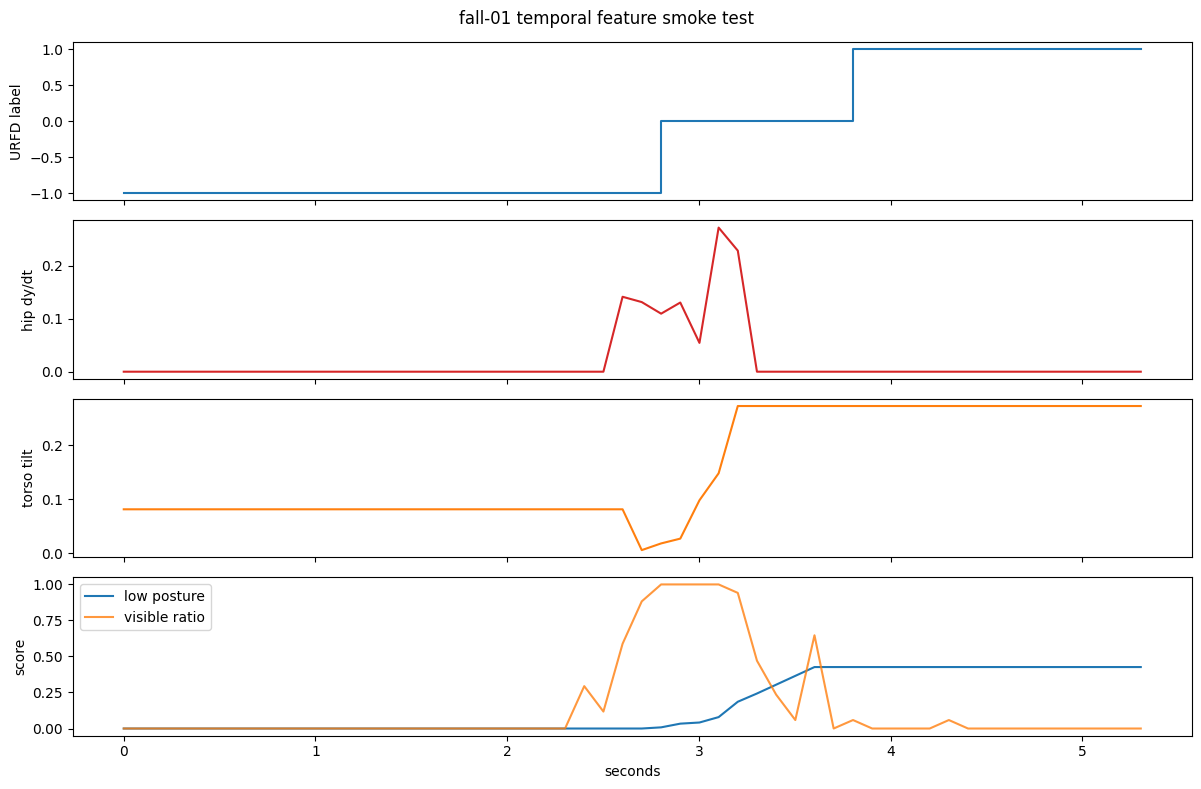

In [18]:
# label 전이와 핵심 파생 특징을 같은 시간축에서 확인
figure, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].step(timestamps_s, sequence_labels, where="post")
axes[0].set_ylabel("URFD label")
axes[1].plot(timestamps_s, hip_vertical_velocity, color="tab:red")
axes[1].set_ylabel("hip dy/dt")
axes[2].plot(timestamps_s, torso_tilt, color="tab:orange")
axes[2].set_ylabel("torso tilt")
axes[3].plot(timestamps_s, low_posture_score, label="low posture")
axes[3].plot(timestamps_s, visible_ratio, label="visible ratio", alpha=0.8)
axes[3].set_ylabel("score")
axes[3].set_xlabel("seconds")
axes[3].legend(loc="upper left")
figure.suptitle("fall-01 temporal feature smoke test")
figure.tight_layout()
plt.show()

# 6. 2초·3초 temporal window

원본 sequence를 섞기 전에 window를 만들고, 낙상 전이·낙상 이후 context·window 마지막 자세를 서로 다른 target으로 보존

In [19]:
WINDOW_SECONDS = (2.0, 3.0)
WINDOW_STRIDE_SECONDS = 0.5
TARGET_NAMES = ("fall_transition", "fall_context", "lying_at_end")

# 한 원본 sequence 안에서 시간 순서를 유지한 sliding window를 생성
def build_temporal_windows(
    features: np.ndarray,
    labels: np.ndarray,
    sequence_id: str,
    sequence_class: str,
    fps: float,
    window_seconds: float,
    stride_seconds: float = WINDOW_STRIDE_SECONDS,
) -> dict[str, np.ndarray]:
    window_size = int(round(window_seconds * fps))
    stride = max(1, int(round(stride_seconds * fps)))
    windows, targets, starts, ends = [], [], [], []

    for start in range(0, len(features) - window_size + 1, stride):
        end = start + window_size
        label_window = labels[start:end]
        is_fall_sequence = sequence_class == "fall"

        # event 전이·후속 context·마지막 자세를 별도 target으로 유지
        windows.append(features[start:end])
        targets.append([
            int(is_fall_sequence and np.any(label_window == 0)),
            int(is_fall_sequence and np.any(label_window >= 0)),
            int(label_window[-1] == 1),
        ])
        starts.append(start)
        ends.append(end - 1)

    return {
        "features": np.asarray(windows, dtype=np.float32),
        "targets": np.asarray(targets, dtype=np.int64),
        "start_indices": np.asarray(starts, dtype=np.int32),
        "end_indices": np.asarray(ends, dtype=np.int32),
        "sequence_ids": np.asarray([sequence_id] * len(windows)),
    }

print(f"Window candidates: {WINDOW_SECONDS} seconds, stride={WINDOW_STRIDE_SECONDS}s")

Window candidates: (2.0, 3.0) seconds, stride=0.5s


In [20]:
# 같은 feature sequence로 2초·3초 window shape와 target 분포를 비교
window_sets = {
    seconds: build_temporal_windows(
        feature_matrix, sequence_labels, "fall-01", "fall",
        effective_fps, seconds,
    )
    for seconds in WINDOW_SECONDS
}

for seconds, window_set in window_sets.items():
    positive_counts = dict(zip(TARGET_NAMES, window_set["targets"].sum(axis=0).tolist()))
    print(
        f"{seconds:.0f}s windows: shape={window_set['features'].shape}, "
        f"positive targets={positive_counts}"
    )

SMOKE_WINDOW_SECONDS = 2.0
SMOKE_DATA_PATH = PROCESSED_DATA_DIR / "fall-01_temporal-window-smoke.npz"
smoke_windows = window_sets[SMOKE_WINDOW_SECONDS]

# 학습 전 단계의 재실행 확인용 artifact만 ignored data path에 저장
np.savez_compressed(
    SMOKE_DATA_PATH,
    features=smoke_windows["features"],
    targets=smoke_windows["targets"],
    start_indices=smoke_windows["start_indices"],
    end_indices=smoke_windows["end_indices"],
    sequence_ids=smoke_windows["sequence_ids"],
    target_names=np.asarray(TARGET_NAMES),
    feature_count=np.asarray(feature_matrix.shape[1]),
    window_seconds=np.asarray(SMOKE_WINDOW_SECONDS),
    bbox_strategy=np.asarray(BBOX_STRATEGY),
)
print(f"Smoke artifact: {SMOKE_DATA_PATH.relative_to(PROJECT_ROOT)}")
print("Window generation: PASS")

2s windows: shape=(7, 20, 80), positive targets={'fall_transition': 5, 'fall_context': 5, 'lying_at_end': 3}
3s windows: shape=(5, 30, 80), positive targets={'fall_transition': 5, 'fall_context': 5, 'lying_at_end': 3}
Smoke artifact: ml/data/processed/m04/fall-01_temporal-window-smoke.npz
Window generation: PASS


# 7. 규칙 기반 낙상 판단 smoke baseline

`lying` 단독 판단과 하강·몸통 기울기·낮은 자세 지속·회복·관절 품질을 결합한 판단을 같은 2초 window에서 비교한다. 단일 `fall-01`과 fallback bbox 결과이므로 metric은 구현 검증용이며 모델 채택 근거가 아니다.

In [21]:
RULE_THRESHOLDS = {
    "descent_velocity": 0.20,
    "torso_tilt": 0.35,
    "low_posture": 0.55,
    "recovery": 0.25,
    "visible_ratio": 0.50,
}
derived_offset = 17 * 2 + 17 + 17
derived_index = {name: derived_offset + index for index, name in enumerate(derived_feature_names)}
rule_features = smoke_windows["features"]
tail_frames = max(1, int(round(0.5 * effective_fps)))

# 각 window를 event 판단에 필요한 소수의 설명 가능한 값으로 요약
descent_peak = rule_features[:, :, derived_index["hip_vertical_velocity"]].max(axis=1)
tilt_peak = rule_features[:, :, derived_index["torso_tilt"]].max(axis=1)
low_posture_peak = rule_features[:, :, derived_index["low_posture_score"]].max(axis=1)
low_posture_tail = rule_features[:, -tail_frames:, derived_index["low_posture_score"]].mean(axis=1)
recovery_amount = low_posture_peak - low_posture_tail
window_visible_ratio = rule_features[:, :, derived_index["visible_ratio"]].mean(axis=1)

lying_only_predictions = (low_posture_tail >= RULE_THRESHOLDS["low_posture"]).astype(np.int64)
combined_predictions = (
    (descent_peak >= RULE_THRESHOLDS["descent_velocity"])
    & (
        (tilt_peak >= RULE_THRESHOLDS["torso_tilt"])
        | (low_posture_tail >= RULE_THRESHOLDS["low_posture"])
    )
    & (recovery_amount < RULE_THRESHOLDS["recovery"])
    & (window_visible_ratio >= RULE_THRESHOLDS["visible_ratio"])
).astype(np.int64)
fall_context_target_index = TARGET_NAMES.index("fall_context")
rule_targets = smoke_windows["targets"][:, fall_context_target_index]

print(f"Rule windows: {len(rule_targets)}")
print(f"Combined positives: {int(combined_predictions.sum())}")

Rule windows: 7
Combined positives: 0


In [22]:
# 외부 metric package 없이 두 rule의 precision·recall·F1을 같은 방식으로 계산
def binary_metrics(targets: np.ndarray, predictions: np.ndarray) -> dict[str, float]:
    true_positive = int(np.sum((targets == 1) & (predictions == 1)))
    false_positive = int(np.sum((targets == 0) & (predictions == 1)))
    false_negative = int(np.sum((targets == 1) & (predictions == 0)))
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)
    return {"precision": precision, "recall": recall, "f1": f1}

rule_metric_rows = {
    "lying_only": binary_metrics(rule_targets, lying_only_predictions),
    "combined": binary_metrics(rule_targets, combined_predictions),
}
for rule_name, metrics in rule_metric_rows.items():
    print(
        f"{rule_name:>12}: precision={metrics['precision']:.3f}, "
        f"recall={metrics['recall']:.3f}, f1={metrics['f1']:.3f}"
    )

  lying_only: precision=0.000, recall=0.000, f1=0.000
    combined: precision=0.000, recall=0.000, f1=0.000


In [23]:
# 가장 최근 window를 공통 M-04 event 후보 형식으로 변환
latest_index = len(combined_predictions) - 1
evidence_score = float(np.mean(np.clip([
    descent_peak[latest_index] / RULE_THRESHOLDS["descent_velocity"],
    tilt_peak[latest_index] / RULE_THRESHOLDS["torso_tilt"],
    low_posture_tail[latest_index] / RULE_THRESHOLDS["low_posture"],
], 0.0, 1.0)))
quality_factor = float(np.clip(
    window_visible_ratio[latest_index] / RULE_THRESHOLDS["visible_ratio"], 0.0, 1.0
))

# 낮은 관절 품질과 recovery는 fall confidence를 직접 낮춤
recovery_factor = float(np.clip(
    1.0 - recovery_amount[latest_index] / RULE_THRESHOLDS["recovery"], 0.0, 1.0
))
rule_confidence = evidence_score * quality_factor * recovery_factor
rule_result = {
    "track_id": TRACK_ID,
    "timestamp_ms": int(sequence_timestamps_ms[smoke_windows["end_indices"][latest_index]]),
    "fall_suspected": bool(combined_predictions[latest_index]),
    "confidence": rule_confidence,
    "reason": {
        "descent_peak": float(descent_peak[latest_index]),
        "torso_tilt_peak": float(tilt_peak[latest_index]),
        "low_posture_tail": float(low_posture_tail[latest_index]),
        "recovery_amount": float(recovery_amount[latest_index]),
        "visible_ratio": float(window_visible_ratio[latest_index]),
        "quality_gate_pass": bool(
            window_visible_ratio[latest_index] >= RULE_THRESHOLDS["visible_ratio"]
        ),
    },
}
print(f"Rule output: {rule_result}")
print("Rule baseline contract: PASS (smoke-test metric only)")

Rule output: {'track_id': 1, 'timestamp_ms': 4905, 'fall_suspected': False, 'confidence': 0.3807425678104234, 'reason': {'descent_peak': 0.27140897512435913, 'torso_tilt_peak': 0.2727842330932617, 'low_posture_tail': 0.42657971382141113, 'recovery_amount': 0.0, 'visible_ratio': 0.2235294133424759, 'quality_gate_pass': False}}
Rule baseline contract: PASS (smoke-test metric only)


# 8. 원본 sequence 단위 split

같은 원본 sequence에서 겹쳐 생성된 window가 서로 다른 split으로 새지 않도록 30개 fall·40개 ADL sequence ID를 먼저 분리한다. URFD는 subject ID를 제공하지 않으므로 이 baseline은 sequence group을 사용한다.

In [24]:
import json

SPLIT_SEED = "wardy-m04-v1"
SPLIT_RATIOS = (0.70, 0.15, 0.15)
catalog = [
    {"sequence_id": f"fall-{index:02d}", "sequence_class": "fall"}
    for index in range(1, 31)
] + [
    {"sequence_id": f"adl-{index:02d}", "sequence_class": "adl"}
    for index in range(1, 41)
]

# class별 sequence ID를 stable hash로 정렬한 뒤 70/15/15로 분할
def assign_group_splits(rows: list[dict[str, str]]) -> list[dict[str, str]]:
    assigned = []
    for sequence_class in sorted({row["sequence_class"] for row in rows}):
        class_rows = [row.copy() for row in rows if row["sequence_class"] == sequence_class]
        class_rows.sort(
            key=lambda row: hashlib.sha256(
                f"{SPLIT_SEED}:{row['sequence_id']}".encode()
            ).hexdigest()
        )
        train_end = int(len(class_rows) * SPLIT_RATIOS[0])
        validation_end = train_end + int(len(class_rows) * SPLIT_RATIOS[1])
        for index, row in enumerate(class_rows):
            row["split"] = (
                "train" if index < train_end
                else "validation" if index < validation_end
                else "test"
            )
            assigned.append(row)
    return sorted(assigned, key=lambda row: row["sequence_id"])

catalog = assign_group_splits(catalog)
print(f"Sequence catalog: {len(catalog)} groups")

Sequence catalog: 70 groups


In [25]:
# 같은 sequence가 여러 split에 섞이지 않는지 집합 단위로 검증
split_groups = {
    split: {row["sequence_id"] for row in catalog if row["split"] == split}
    for split in ("train", "validation", "test")
}
assert split_groups["train"].isdisjoint(split_groups["validation"])
assert split_groups["train"].isdisjoint(split_groups["test"])
assert split_groups["validation"].isdisjoint(split_groups["test"])

# 재현 가능한 결과는 이후 전체 데이터 준비 단계가 재사용하도록 manifest로 저장
split_counts = Counter((row["split"], row["sequence_class"]) for row in catalog)
SPLIT_MANIFEST_PATH = PROCESSED_DATA_DIR / "urfd_sequence_split_v1.json"
SPLIT_MANIFEST_PATH.write_text(
    json.dumps({"seed": SPLIT_SEED, "ratios": SPLIT_RATIOS, "sequences": catalog}, indent=2) + "\n"
)

for split in ("train", "validation", "test"):
    print(
        f"{split:>10}: fall={split_counts[(split, 'fall')]:2d}, "
        f"adl={split_counts[(split, 'adl')]:2d}"
    )
print(f"Split manifest: {SPLIT_MANIFEST_PATH.relative_to(PROJECT_ROOT)}")
print("Sequence leakage check: PASS")

     train: fall=21, adl=28
validation: fall= 4, adl= 6
      test: fall= 5, adl= 6
Split manifest: ml/data/processed/m04/urfd_sequence_split_v1.json
Sequence leakage check: PASS


# 9. PyTorch dataset와 학습 준비 확인

학습 code가 받을 tensor shape·dtype·target index를 고정하고, 현재 확보된 sequence가 실제 train·validation·test 학습을 시작하기에 충분한지 별도로 판정

In [26]:
from torch.utils.data import DataLoader, Dataset

# 실제 학습에서는 train split으로만 mean/std를 fit하고 validation·test에는 재사용
def fit_feature_standardizer(train_features: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    feature_mean = train_features.mean(axis=(0, 1), keepdims=True).astype(np.float32)
    feature_std = train_features.std(axis=(0, 1), keepdims=True).astype(np.float32)
    feature_std = np.where(feature_std < 1e-6, 1.0, feature_std).astype(np.float32)
    return feature_mean, feature_std

def standardize_features(
    features: np.ndarray, feature_mean: np.ndarray, feature_std: np.ndarray
) -> np.ndarray:
    return ((features - feature_mean) / feature_std).astype(np.float32)

smoke_feature_mean, smoke_feature_std = fit_feature_standardizer(smoke_windows["features"])
standardized_smoke_features = standardize_features(
    smoke_windows["features"], smoke_feature_mean, smoke_feature_std
)
assert np.allclose(standardized_smoke_features.mean(axis=(0, 1)), 0.0, atol=1e-4)
print("Feature standardizer: PASS (smoke fit; real fit must use train split only)")

Feature standardizer: PASS (smoke fit; real fit must use train split only)


In [27]:
# numpy window를 PyTorch가 읽을 feature/target tensor pair로 노출
class PoseWindowDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray, target_index: int = 1):
        if len(features) != len(targets):
            raise ValueError("features and targets must have the same length")
        self.features = torch.from_numpy(features.astype(np.float32, copy=False))
        self.targets = torch.from_numpy(targets[:, target_index].astype(np.int64, copy=False))

    def __len__(self) -> int:
        return len(self.features)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.features[index], self.targets[index]

FALL_CONTEXT_TARGET_INDEX = TARGET_NAMES.index("fall_context")
smoke_dataset = PoseWindowDataset(
    standardized_smoke_features, smoke_windows["targets"], FALL_CONTEXT_TARGET_INDEX
)
smoke_loader = DataLoader(smoke_dataset, batch_size=4, shuffle=False, num_workers=0)
batch_features, batch_targets = next(iter(smoke_loader))

assert batch_features.ndim == 3
assert batch_features.dtype == torch.float32
assert batch_targets.dtype == torch.int64
assert torch.isfinite(batch_features).all()

# 첫 batch로 shape·dtype·finite-value 계약을 학습 코드 진입 전에 확인
print(f"Dataset windows: {len(smoke_dataset)}")
print(f"Batch features: shape={tuple(batch_features.shape)}, dtype={batch_features.dtype}")
print(f"Batch targets: shape={tuple(batch_targets.shape)}, values={batch_targets.tolist()}")
print(f"Model input contract: [batch, time, feature] = {tuple(batch_features.shape)}")
print("PyTorch data contract: PASS")

Dataset windows: 7
Batch features: shape=(4, 20, 80), dtype=torch.float32
Batch targets: shape=(4,), values=[0, 0, 1, 1]
Model input contract: [batch, time, feature] = (4, 20, 80)
PyTorch data contract: PASS


In [28]:
# 실제 archive 확보 상태와 bbox 품질 gate를 학습 시작 조건으로 검사
available_archives = sorted(URFD_DIR.glob("*-cam0-rgb.zip"))
available_sequence_ids = {path.name.replace("-cam0-rgb.zip", "") for path in available_archives}
available_rows = [row for row in catalog if row["sequence_id"] in available_sequence_ids]
available_counts = Counter((row["split"], row["sequence_class"]) for row in available_rows)
readiness_reasons = []

for split in ("train", "validation", "test"):
    for sequence_class in ("fall", "adl"):
        if available_counts[(split, sequence_class)] == 0:
            readiness_reasons.append(f"missing {sequence_class} sequence in {split}")
if BBOX_STRATEGY == "full_frame_fallback":
    readiness_reasons.append("M-01 bbox or reviewed person-box manifest not connected")
if not pose_input_quality_ready:
    readiness_reasons.append(
        "pose quality/visible-joint ratio below the reviewed training gate"
    )

training_ready = len(readiness_reasons) == 0
print(f"Available RGB sequences: {len(available_rows)}/70")
print(f"Training ready: {training_ready}")
for reason in readiness_reasons:
    print(f"  - {reason}")
print("Pre-training pipeline implementation: PASS")

Available RGB sequences: 1/70
Training ready: False
  - missing adl sequence in train
  - missing fall sequence in validation
  - missing adl sequence in validation
  - missing fall sequence in test
  - missing adl sequence in test
  - M-01 bbox or reviewed person-box manifest not connected
  - pose quality/visible-joint ratio below the reviewed training gate
Pre-training pipeline implementation: PASS


# 10. 모델 학습 경계

여기까지 완료된 결과는 다음과 같다.

- 공식 RGB·timestamp·frame label의 검증된 입력 계약
- M-03 COCO-17 sequence와 confidence mask
- 하강·기울기·낮은 자세·움직임 파생 특징
- 2초·3초 window와 sequence group split
- `[batch, time, feature]` PyTorch 입력 계약

현재 `fall-01`과 full-frame fallback은 pipeline smoke test다. 모든 split의 fall·ADL archive와 M-01 bbox 또는 검수된 person-box manifest가 준비되면, 이 아래에서 1D CNN·TCN·소형 GRU의 model class, loss, optimizer와 training loop를 추가한다.